# **VAE Architecture**

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ----------------------------
# Encoder Network
# ----------------------------
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  # 28x28 -> 14x14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # 14x14 -> 7x7
            nn.ReLU()
        )
        self.flatten = nn.Flatten()
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = self.flatten(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

# ----------------------------
# Decoder Network (Using Beta)
# ----------------------------
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(latent_dim, 64 * 7 * 7)
        self.deconv_base = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU()
        )

        self.alpha_head = nn.Conv2d(32, 1, kernel_size=3, padding=1)
        self.beta_head = nn.Conv2d(32, 1, kernel_size=3, padding=1)

    def forward(self, z):
        x = self.fc(z).view(-1, 64, 7, 7)
        x = self.deconv_base(x)
        alpha = F.softplus(self.alpha_head(x)) + 1e-3  
        beta = F.softplus(self.beta_head(x)) + 1e-3
        return alpha, beta

# ----------------------------
# VAE Wrapper
# ----------------------------
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu_z, logvar_z = self.encoder(x)
        z = self.reparameterize(mu_z, logvar_z)
        alpha, beta = self.decoder(z)
        return alpha, beta, mu_z, logvar_z, z



In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import torchvision.utils as vutils

def get_mnist_dataloaders(batch_size=128):
    def transform_fn(x):
        x = transforms.ToTensor()(x)
        return (x * 0.98 + 0.01)  # now in [0.01, 0.99]
    
    full_train_set = datasets.MNIST('./data', train=True, download=True, transform=transform_fn)
    test_set = datasets.MNIST('./data', train=False, download=True, transform=transform_fn)
    train_set, val_set = random_split(full_train_set, [50000, 10000])
    return (
        DataLoader(train_set, batch_size=batch_size, shuffle=True),
        DataLoader(val_set, batch_size=batch_size, shuffle=False),
        DataLoader(test_set, batch_size=batch_size, shuffle=False)
    )

def elbo_loss(x, alpha, beta, mu_z, logvar_z, beta_kl):
    B = x.size(0)
    x = x.view(B, -1)
    alpha = alpha.view(B, -1)
    beta = beta.view(B, -1)

    eps = 1e-6
    x = torch.clamp(x, eps, 1 - eps)

    log_likelihood = (
        torch.lgamma(alpha + beta)
        - torch.lgamma(alpha)
        - torch.lgamma(beta)
        + (alpha - 1) * torch.log(x)
        + (beta - 1) * torch.log(1 - x)
    )
    recon_loss = -torch.sum(log_likelihood, dim=1)

    kl_div = -0.5 * torch.sum(1 + logvar_z - mu_z.pow(2) - logvar_z.exp(), dim=1)

    return torch.mean(recon_loss + beta_kl * kl_div)




In [3]:
import torch
import matplotlib.pyplot as plt

def train_vae(model, train_loader, val_loader, optimizer,
                                   num_epochs=100, patience=10, device='cuda'):

    model = model.to(device)
    train_elbo, val_elbo = [], []

    best_val_elbo = float('-inf')
    epochs_without_improvement = 0

    for epoch in range(1, num_epochs + 1):
        #beta_kl = min(10.0, epoch / 50 * 10)
        beta_kl = 10

        model.train()
        total_train_loss = 0
        for x_batch, _ in train_loader:
            x_batch = x_batch.to(device)
            optimizer.zero_grad()
            mu_x, logvar_x, mu_z, logvar_z, _ = model(x_batch)
            loss = elbo_loss(x_batch, mu_x, logvar_x, mu_z, logvar_z, beta_kl)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_elbo.append(-avg_train_loss)

        # --- Validation ---
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for x_val, _ in val_loader:
                x_val = x_val.to(device)
                mu_x, logvar_x, mu_z, logvar_z, _ = model(x_val)
                loss = elbo_loss(x_val, mu_x, logvar_x, mu_z, logvar_z, beta_kl)
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_elbo.append(-avg_val_loss)
        

        print(f"Epoch {epoch:02d} | Train ELBO: {-avg_train_loss:.4f} | Val ELBO: {-avg_val_loss:.4f}")

        # Early stopping logic
        if -avg_val_loss > best_val_elbo:
            best_val_elbo = -avg_val_loss
            epochs_without_improvement = 0
            best_model_state = model.state_dict()
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Stopping early at epoch {epoch} due to no improvement in validation ELBO.")
            break

    # Restore best model
    model.load_state_dict(best_model_state)

    # Plot ELBO
    plt.plot(train_elbo, label='Train ELBO')
    plt.plot(val_elbo, label='Validation ELBO')
    plt.xlabel('Epoch')
    plt.ylabel('ELBO')
    plt.legend()
    plt.title('ELBO vs Epoch')
    plt.show()

    return train_elbo, val_elbo



In [4]:
import torchvision.utils as vutils

def test_vae_reconstruction_and_generation(model, test_loader, device='cuda'):
    model.eval()
    model = model.to(device)

    # Get a single batch from test set
    x_test, _ = next(iter(test_loader))
    x_test = x_test[:32].to(device)  # use only first 32 for display
    with torch.no_grad():
        mu_z, logvar_z = model.encoder(x_test)
        z = model.reparameterize(mu_z, logvar_z)
        alpha, beta = model.decoder(z)
        alpha = torch.clamp(alpha, min=1e-3)
        beta = torch.clamp(beta, min=1e-3)
        recon_x = torch.distributions.Beta(alpha, beta).sample()

    # Arrange originals and reconstructions side-by-side
    grid = torch.cat([x_test.cpu(), recon_x.cpu()], dim=0)
    grid_img = vutils.make_grid(grid, nrow=8, pad_value=1)

    plt.figure(figsize=(8, 8))
    plt.axis('off')
    plt.title('Top: Original | Bottom: Reconstruction')
    plt.imshow(grid_img.permute(1, 2, 0), cmap='gray')
    plt.show()

def generate_from_prior(model, num_samples=64, device='cuda'):
    model.eval()
    model = model.to(device)

    with torch.no_grad():
        z = torch.randn(num_samples, model.encoder.fc_mu.out_features).to(device)
        alpha, beta = model.decoder(z)
        # alpha = torch.clamp(alpha, min=1e-3)
        # beta = torch.clamp(beta, min=1e-3)
        gen_x = torch.distributions.Beta(alpha, beta).sample()


    grid_img = vutils.make_grid(gen_x.cpu(), nrow=8, pad_value=1)

    plt.figure(figsize=(8, 8))
    plt.axis('off')
    plt.title('Generated Samples from Prior')
    plt.imshow(grid_img.permute(1, 2, 0), cmap='gray')
    plt.show()


Epoch 01 | Train ELBO: 1952.7523 | Val ELBO: 2598.8336
Epoch 02 | Train ELBO: 2824.1224 | Val ELBO: 3018.0480
Epoch 03 | Train ELBO: 3127.4463 | Val ELBO: 3248.6766
Epoch 04 | Train ELBO: 3305.7495 | Val ELBO: 3410.0231
Epoch 05 | Train ELBO: 3447.2550 | Val ELBO: 3516.0874
Epoch 06 | Train ELBO: 3537.9575 | Val ELBO: 3624.6162
Epoch 07 | Train ELBO: 3628.4528 | Val ELBO: 3699.6553
Epoch 08 | Train ELBO: 3701.2827 | Val ELBO: 3759.9221
Epoch 09 | Train ELBO: 3764.6171 | Val ELBO: 3698.2639
Epoch 10 | Train ELBO: 3804.9287 | Val ELBO: 3804.3354
Epoch 11 | Train ELBO: 3832.2080 | Val ELBO: 3902.7934
Epoch 12 | Train ELBO: 3872.9694 | Val ELBO: 3928.2542
Epoch 13 | Train ELBO: 3911.0214 | Val ELBO: 3964.7499
Epoch 14 | Train ELBO: 3922.5944 | Val ELBO: 3998.2333
Epoch 15 | Train ELBO: 3972.5325 | Val ELBO: 4021.7157
Epoch 16 | Train ELBO: 3985.1510 | Val ELBO: 3962.1195
Epoch 17 | Train ELBO: 4002.2147 | Val ELBO: 4031.2634
Epoch 18 | Train ELBO: 4021.3021 | Val ELBO: 4035.6170
Epoch 19 |

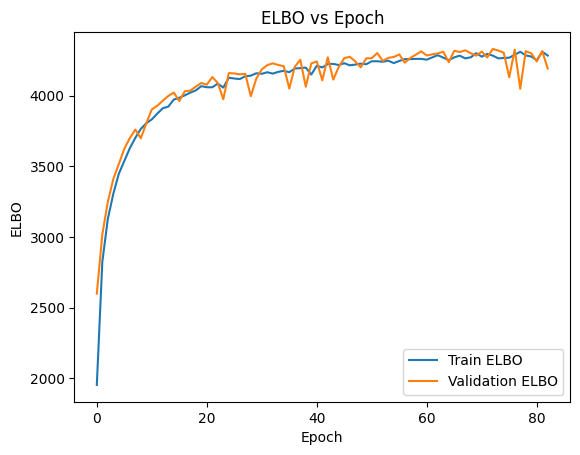

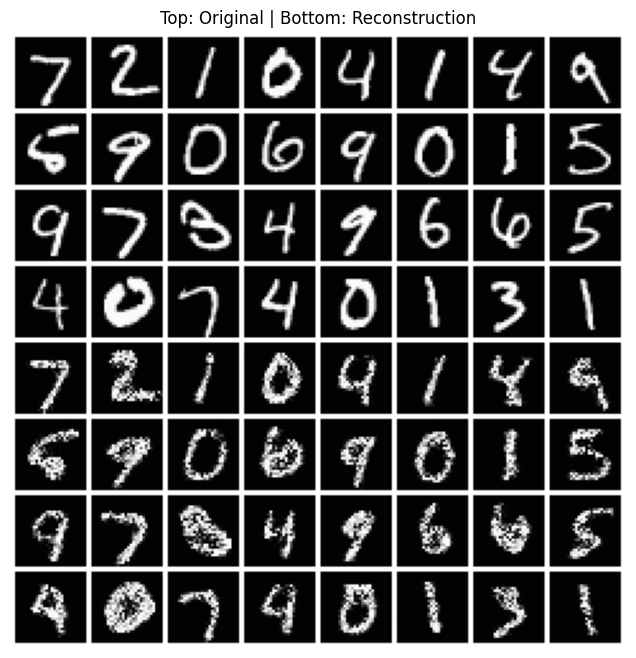

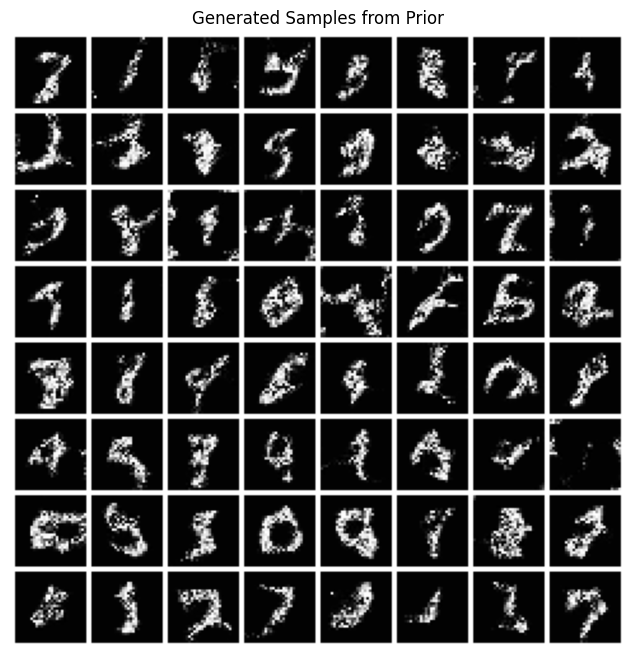

In [5]:
torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
latent_dim = 25
batch_size = 128

train_loader, val_loader, test_loader = get_mnist_dataloaders(batch_size)

model = VAE(latent_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_vae(model, train_loader, val_loader, optimizer, num_epochs=300, patience=10, device=device)
test_vae_reconstruction_and_generation(model, test_loader, device=device)
generate_from_prior(model, num_samples=64, device=device)